# Do adopters already know the partner words?

This notebook is a runnable demo of **`eval.py`**, the adopter-level evaluation of the absorptive-capacity mechanism behind
D2's host-share effect (`A_cont`, co-primary IRR/SD 1.30). All results come from the **screen fold only**, so they are
*mechanism evidence, not confirmation*.

**The question.** Some authors adopt concept *c* in host subfield *d*. Before the entry year *e*, had they already used
*c*'s **partner concepts** (the "partner words")? And did they use them more than matched host authors who never adopted *c*?

**How `eval.py` works.** It runs in five stages:
`prepare` (reproduction gate) → `frame` (cases, risk-set controls, targets) → `freeze` (hashed `mech_spec.json` plus the
simulated MDEs) → `pull` (the OpenAlex validation pull, which was blocked by the credit reserve) → **`analyze`**.

**What this demo runs.** It re-runs the **`analyze` stage's matched-pair analysis**, using the original code from
`eval.py`, `src/analysis.py` and `src/stats_core.py`:
- **M-i**: conditional-logit enrichment, with negative-control (NEG), placebo (PLAC) and swapped-partner comparisons.
- **M-ii**: interaction with `A_cont`.
- **M-iii**: partner vocabulary class (NATIVE / ADJACENT / FOREIGN) and origin companions.
- A concept-cluster bootstrap, a permutation null, match balance, statsmodels and pyfixest cross-checks, subgroup fits,
  and the pre-declared **reading rules**.

**What the demo leaves out, and why.**
- The upstream stages need the 463k-work corpus and the exp_7 results, so the demo does not run them.
- It does not run the corpus-dependent step `compute_exposures` either. `mini_demo_data.json` already contains the
  **exposure columns that step produced**, for **50 matched 1:1 strata (100 authors)**, stratified by `A_cont` tercile out
  of the full 1,013.
- The entry-level PPML mediation (M-iv) needs the 1,544-entry mediator table and the vendored exp_7 PPML code, so it is
  also left out. The reading rules use the full run's frozen mediation result, which is shipped in the data file.

## Setup
Install the packages. On Colab, the pre-installed scientific stack is left untouched.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# pyfixest (LPM cross-check), loguru (logging) — NOT pre-installed on Colab, always install
_pip('pyfixest==0.60.0', 'loguru==0.7.3')

# numpy, pandas, scipy, statsmodels, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'statsmodels==0.14.6', 'matplotlib==3.10.0')

The imports are the original import blocks of `eval.py`, `src/analysis.py` and `src/stats_core.py`, plus matplotlib for the final figure.

In [2]:
from __future__ import annotations

import hashlib
import re
import json
import sys
import time
import warnings
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
from loguru import logger
from scipy import stats

import matplotlib.pyplot as plt

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
import logging

logging.getLogger("fontTools").setLevel(logging.WARNING)

Load the data. The loader reads the file from GitHub first and falls back to a local copy of `mini_demo_data.json`.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_-5obKGrJFD0H/round-4/evaluation-5/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(json.dumps(data["metadata"], indent=1))
print("rows:", len(data["examples"]), "| example row:", data["examples"][0])

{
 "description": "50 matched 1:1 case-control strata (100 rows) drawn from the 1,013-stratum primary frame of the adopter-level absorptive-capacity test, with corpus exposures already computed (the corpus itself is not shipped). Stratified by A_cont tercile (12/13/25 strata), seed 20260929.",
 "label": "screen-fold mechanism evidence, not confirmation",
 "exposure_label": "corpus-exposure, coverage-limited",
 "mech_spec_sha256": "96e697c6970be67be182841fd76eb7e2a583e675eef09d7c482ddbce1f93c293",
 "n_rows": 100,
 "n_strata": 50,
 "n_concepts": 37,
 "full_frame": {
  "n_strata": 1013,
  "n_rows": 2026
 }
}
rows: 100 | example row: {'stratum': 12, 'entry_id': 'c_029ea7c780b8|2205|2018', 'concept_id': 'c_029ea7c780b8', 'd': 2205, 'e': 2018, 'Y': 2019, 'A_tercile': 1, 'A_cont': 0.0090478021, 'field_group': 'CS', 'single_paper_entry': True, 'relax': 0, 'widened': False, 'case': 1, 'role': 'case', 'n_prior_corpus': 1, 'first_year': 2010, 'team_bin': 1, 'act_bin': 0, 'fy_bin': 1, 'prior_bin':

## Config

These are all the tunable parameters. The values in `eval.py` are shown in comments.
- `B` sets the number of concept-cluster bootstrap replicates for the whole model suite (`--B`, default 1000; `--mini` uses 20).
- `N_PERM` sets the number of permutation-null draws (200 in the full run, 50 with `--mini`).
- `Bs` is the bootstrap size for the supplementary subgroup fits. It uses the original formula.

In [5]:
B = 1000           # bootstrap reps for the model suite     (original full run: 1000; smallest tested: 20)
N_PERM = 200      # permutation-null draws                 (original full run: 200; --mini: 50)
MINI = False       # original --mini flag: only switches Bs to 20 below
Bs = max(B // 5, 50) if not MINI else 20   # supplementary bootstrap reps (original formula)

SEED = 20260929    # mc.SEED (frame seed); model seeds are offsets of it, as in eval.py
LABEL = "screen-fold mechanism evidence, not confirmation"
WORKERS = 4        # only used by the (not run) mediation bootstrap in eval.py

## Statistical core (`src/stats_core.py`, verbatim)

`clogit` is a fast Newton-Raphson conditional logistic regression. It allows any number of controls per stratum and
returns model-based SEs and **concept-cluster-robust** (CRV) SEs. Scores are summed per stratum, then per concept.
- `boot_indices` resamples whole concepts with replacement. A concept drawn twice counts as two distinct clusters.
- `pct_ci` gives percentile CIs.
- `boot_p` gives the two-sided bootstrap p-value.
- `smd` gives the standardised mean difference used for match balance.

In [6]:
def clogit(y: np.ndarray, X: np.ndarray, strata: np.ndarray, cluster: np.ndarray | None = None,
           maxit: int = 50, tol: float = 1e-10) -> dict:
    """Conditional logistic regression. y: 0/1 case flag (one case per stratum), X: n x k, strata: int ids."""
    X = np.asarray(X, float)
    if X.ndim == 1:
        X = X[:, None]
    _, s = np.unique(strata, return_inverse=True)
    ns = s.max() + 1
    k = X.shape[1]
    beta = np.zeros(k)
    ll_old = -np.inf
    conv = False
    for it in range(maxit):
        eta = X @ beta
        # stabilise per stratum
        mx = np.full(ns, -np.inf)
        np.maximum.at(mx, s, eta)
        ex = np.exp(eta - mx[s])
        den = np.bincount(s, weights=ex, minlength=ns)
        p = ex / den[s]
        ll = float(np.sum(eta[y == 1] - mx[s[y == 1]] - np.log(den[s[y == 1]])))
        xbar = np.zeros((ns, k))
        np.add.at(xbar, s, p[:, None] * X)
        casex = np.zeros((ns, k))
        np.add.at(casex, s[y == 1], X[y == 1])
        grad = (casex - xbar).sum(0)
        dev = X - xbar[s]
        H = (dev * p[:, None]).T @ dev
        try:
            step = np.linalg.solve(H + 1e-10 * np.eye(k), grad)
        except np.linalg.LinAlgError:
            break
        beta = beta + step
        if abs(ll - ll_old) < tol and np.max(np.abs(step)) < 1e-7:
            conv = True
            break
        ll_old = ll
    eta = X @ beta
    mx = np.full(ns, -np.inf)
    np.maximum.at(mx, s, eta)
    ex = np.exp(eta - mx[s])
    den = np.bincount(s, weights=ex, minlength=ns)
    p = ex / den[s]
    xbar = np.zeros((ns, k))
    np.add.at(xbar, s, p[:, None] * X)
    dev = X - xbar[s]
    H = (dev * p[:, None]).T @ dev
    try:
        Hi = np.linalg.inv(H)
    except np.linalg.LinAlgError:
        Hi = np.full((k, k), np.nan)
    se = np.sqrt(np.clip(np.diag(Hi), 0, None))
    out = {"beta": beta, "se": se, "converged": conv, "n_strata": int(ns), "n": int(len(y))}
    if cluster is not None:
        casex = np.zeros((ns, k))
        np.add.at(casex, s[y == 1], X[y == 1])
        score_s = casex - xbar  # per-stratum score
        cl_s = np.zeros(ns, dtype=np.int64)
        _, cl = np.unique(cluster, return_inverse=True)
        cl_s[s] = cl
        G = cl.max() + 1
        S = np.zeros((G, k))
        np.add.at(S, cl_s, score_s)
        V = G / (G - 1) * Hi @ (S.T @ S) @ Hi if G > 1 else Hi
        out["se_crv"] = np.sqrt(np.clip(np.diag(V), 0, None))
        out["G"] = int(G)
    return out


def boot_indices(cluster_of_row: np.ndarray, rng: np.random.Generator) -> tuple[np.ndarray, np.ndarray]:
    """Concept-cluster bootstrap: returns row indices and a replicate-cluster id per row (duplicates distinct)."""
    uc, inv = np.unique(cluster_of_row, return_inverse=True)
    rows_by = [np.flatnonzero(inv == i) for i in range(len(uc))]
    draw = rng.integers(0, len(uc), len(uc))
    idx = np.concatenate([rows_by[j] for j in draw])
    rep = np.concatenate([np.full(len(rows_by[j]), t) for t, j in enumerate(draw)])
    return idx, rep


def pct_ci(x: np.ndarray, alpha: float = 0.05) -> list[float]:
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) < 10:
        return [float("nan"), float("nan")]
    return [float(np.quantile(x, alpha / 2)), float(np.quantile(x, 1 - alpha / 2))]


def boot_p(x: np.ndarray, null: float = 0.0) -> float:
    """Two-sided bootstrap p: 2 x min share of replicates on either side of the null (floored at 1/(B+1))."""
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return float("nan")
    p = 2 * min((x <= null).mean(), (x >= null).mean())
    return float(max(min(p, 1.0), 1 / (len(x) + 1)))


def wald_p(b: float, se: float) -> float:
    return float(2 * stats.norm.sf(abs(b / se))) if se and np.isfinite(se) and se > 0 else float("nan")


def smd(a: np.ndarray, b: np.ndarray) -> float:
    a, b = np.asarray(a, float), np.asarray(b, float)
    a, b = a[np.isfinite(a)], b[np.isfinite(b)]
    sd = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    return float((a.mean() - b.mean()) / sd) if sd > 0 else 0.0

## Model set, bootstrap and checks (`src/analysis.py`, verbatim)

Every model is a conditional logit of `case` on exposure indicators within matched strata. All exposures are measured
from the member's corpus works published **up to e-1**, with c-papers excluded.

| Model | Terms | Question it answers |
|---|---|---|
| `m2` (**primary**) | `E_any + E_neg + lp` | Did the author use ≥1 of the entry's partner concepts, holding generic host vocabulary (NEG) and prior output (`lp` = log1p prior works) fixed? |
| `m_plac` | `+ E_plac` | Compares with the partner set of **another** concept's entry into the same host (placebo), on strata that have one |
| `m_swap` | `E_swap` | Label shuffle: uses another entry's full partner set |
| `m_int` | `+ E_any × z(A_cont)` | Is enrichment stronger where partners are host-native (high `A_cont`)? |
| `m_voc` | `E_nat + E_adj + E_for + E_unprof` | Which partner vocabulary class carries the enrichment? |
| `m_comp` | `E_comp + E_noncomp` | Origin-companion partners vs other partners |

`full_block` fits every model and then runs the **concept-cluster bootstrap** over the whole suite. It also forms OR
ratios, such as `partner/NEG` and `partner/PLAC`, from paired bootstrap draws.

In [7]:
MODELS = {
    "m1": ["E_any", "lp"],
    "m2": ["E_any", "E_neg", "lp"],                      # PRIMARY estimand: OR(E_any | E_neg, prior_n)
    "m3": ["E_w", "E_neg", "lp"],
    "m_neg_only": ["E_neg", "lp"],
    "m_plac": ["E_any", "E_neg", "E_plac", "lp"],        # strata with a placebo entry only
    "m_plac_only": ["E_plac", "lp"],                     # strata with a placebo entry only
    "m_int": ["E_any", "E_neg", "lp", "E_any_x_zA"],
    "m_voc": ["E_nat", "E_adj", "E_for", "E_unprof", "E_neg", "lp"],
    "m_comp": ["E_comp", "E_noncomp", "E_neg", "lp"],
    "m_swap": ["E_swap", "E_neg", "lp"],                 # label shuffle: another entry's partner set, same host-year
    "m_any_incl_c": ["E_any_incl_c", "E_neg", "lp"],
}
PLAC_MODELS = {"m_plac", "m_plac_only", "m_swap"}


def add_design(D: pd.DataFrame, sdA: float, mA: float) -> pd.DataFrame:
    D = D.copy()
    D["lp"] = np.log1p(D.n_prior_corpus.astype(float))
    D["zA"] = (D.A_cont - mA) / sdA
    D["E_any_x_zA"] = D.E_any * D.zA
    return D


# ------------------------------------------------------------------ model set + bootstrap
def fit_model(D: pd.DataFrame, cols: list[str], cluster: bool = True) -> dict | None:
    X = D[cols].to_numpy(float)
    keep = np.ones(len(cols), bool)
    # drop exposure columns without any within-stratum variation (unidentified)
    s = D.stratum.to_numpy()
    for j in range(len(cols)):
        mx = pd.Series(X[:, j]).groupby(s).agg(lambda z: z.max() - z.min())
        if (mx > 0).sum() == 0:
            keep[j] = False
    if keep.sum() == 0:
        return None
    r = clogit(D.case.to_numpy(), X[:, keep], s, D.cluster.to_numpy() if cluster else None)
    beta = np.full(len(cols), np.nan)
    se = np.full(len(cols), np.nan)
    sec = np.full(len(cols), np.nan)
    beta[keep], se[keep] = r["beta"], r["se"]
    if cluster:
        sec[keep] = r["se_crv"]
    return {"cols": cols, "beta": beta, "se": se, "se_crv": sec, "n_strata": r["n_strata"], "n": r["n"],
            "converged": r["converged"]}


def fast_betas(D: pd.DataFrame, cols: list[str]) -> np.ndarray:
    X = D[cols].to_numpy(float)
    try:
        r = clogit(D.case.to_numpy(), X, D.stratum.to_numpy(), None, maxit=30)
        b = r["beta"]
        b[np.abs(b) > 15] = np.nan  # separation in a replicate
        return b
    except (np.linalg.LinAlgError, FloatingPointError, ValueError):
        return np.full(len(cols), np.nan)


def model_suite(D: pd.DataFrame) -> dict:
    out = {}
    Dp = D[D.has_plac_stratum == 1]
    for name, cols in MODELS.items():
        out[name] = fast_betas(Dp if name in PLAC_MODELS else D, cols)
    for t in (1, 2, 3):
        Dt = D[D.A_tercile == t]
        out[f"m2_T{t}"] = fast_betas(Dt, MODELS["m2"]) if Dt.stratum.nunique() >= 20 else np.full(3, np.nan)
    return out


def bootstrap(D: pd.DataFrame, B: int, seed: int) -> dict:
    rng = np.random.default_rng(seed)
    st = D.drop_duplicates("stratum")[["stratum", "cluster"]]
    rows_by_stratum = D.groupby("stratum").indices
    reps = {}
    for b in range(B):
        sidx, rep = boot_indices(st.cluster.to_numpy(), rng)
        chosen = st.stratum.to_numpy()[sidx]
        parts, sid = [], []
        for k, s_ in enumerate(chosen):
            ix = rows_by_stratum[s_]
            parts.append(ix)
            sid.append(np.full(len(ix), k))
        ix = np.concatenate(parts)
        Db = D.iloc[ix].copy()
        Db["stratum"] = np.concatenate(sid)
        res = model_suite(Db)
        for k, v in res.items():
            reps.setdefault(k, []).append(v)
    return {k: np.vstack(v) for k, v in reps.items()}


def summarize_model(name: str, fit: dict | None, boots: np.ndarray | None) -> dict:
    if fit is None:
        return {"model": name, "identified": False}
    out = {"model": name, "n_strata": fit["n_strata"], "n_rows": fit["n"], "converged": fit["converged"], "terms": {}}
    for j, c in enumerate(fit["cols"]):
        b = fit["beta"][j]
        term = {"beta": b, "OR": float(np.exp(b)) if np.isfinite(b) else None, "se_model": fit["se"][j],
                "se_crv_concept": fit["se_crv"][j], "p_model": wald_p(b, fit["se"][j]),
                "p_crv": wald_p(b, fit["se_crv"][j])}
        if boots is not None:
            bb = boots[:, j]
            ci = pct_ci(bb)
            term.update({"OR_ci95_boot": [float(np.exp(ci[0])), float(np.exp(ci[1]))] if np.isfinite(ci[0]) else None,
                         "p_boot": boot_p(bb), "boot_valid": int(np.isfinite(bb).sum())})
        out["terms"][c] = term
    return out


def ratio_summary(fit: dict, boots: np.ndarray, a: str, b: str) -> dict:
    ja, jb = fit["cols"].index(a), fit["cols"].index(b)
    est = fit["beta"][ja] - fit["beta"][jb]
    bb = boots[:, ja] - boots[:, jb]
    ci = pct_ci(bb)
    return {"log_ratio": est, "ratio": float(np.exp(est)) if np.isfinite(est) else None,
            "ci95_boot": [float(np.exp(ci[0])), float(np.exp(ci[1]))] if np.isfinite(ci[0]) else None,
            "p_boot": boot_p(bb), "log_contrast_ci95": ci}


def full_block(D: pd.DataFrame, B: int, seed: int) -> dict:
    """Point fits (with CRV SE) + concept-cluster bootstrap for the whole model suite."""
    fits = {}
    Dp = D[D.has_plac_stratum == 1]
    for name, cols in MODELS.items():
        fits[name] = fit_model(Dp if name in PLAC_MODELS else D, cols)
    for t in (1, 2, 3):
        Dt = D[D.A_tercile == t]
        fits[f"m2_T{t}"] = fit_model(Dt, MODELS["m2"]) if Dt.stratum.nunique() >= 20 else None
    boots = bootstrap(D, B, seed) if B > 0 else {}
    summ = {k: summarize_model(k, f, boots.get(k)) for k, f in fits.items()}
    ratios = {}
    if fits["m2"] is not None and B > 0:
        ratios["partner_over_neg"] = ratio_summary(fits["m2"], boots["m2"], "E_any", "E_neg")
    if fits["m_plac"] is not None and B > 0:
        ratios["partner_over_plac"] = ratio_summary(fits["m_plac"], boots["m_plac"], "E_any", "E_plac")
        ratios["partner_over_neg_in_plac_strata"] = ratio_summary(fits["m_plac"], boots["m_plac"], "E_any", "E_neg")
    if fits["m_voc"] is not None and B > 0:
        ratios["native_vs_foreign"] = ratio_summary(fits["m_voc"], boots["m_voc"], "E_nat", "E_for")
        ratios["adjacent_vs_foreign"] = ratio_summary(fits["m_voc"], boots["m_voc"], "E_adj", "E_for")
    if fits["m_comp"] is not None and B > 0:
        ratios["companion_vs_noncompanion"] = ratio_summary(fits["m_comp"], boots["m_comp"], "E_comp", "E_noncomp")
    return {"fits": summ, "ratios": ratios, "_fits": fits, "_boots": boots}


def descriptives(D: pd.DataFrame) -> dict:
    ca, co = D[D.case == 1], D[D.case == 0]
    out = {"n_cases": int(len(ca)), "n_controls": int(len(co)), "n_strata": int(D.stratum.nunique()),
           "n_concepts": int(D.cluster.nunique()), "n_entries": int(D.entry_id.nunique())}
    for c in ["E_any", "E_neg", "E_plac", "E_nat", "E_adj", "E_for", "E_unprof", "E_comp", "E_noncomp", "E_swap",
              "E_any_incl_c"]:
        out[f"prev_case_{c}"] = float(ca[c].mean())
        out[f"prev_control_{c}"] = float(co[c].mean())
    out["mean_case_E_w"], out["mean_control_E_w"] = float(ca.E_w.mean()), float(co.E_w.mean())
    # discordant pairs (1:1)
    w = D.pivot_table(index="stratum", columns="case", values="E_any", aggfunc="max")
    out["discordant_case_only"] = int(((w[1] == 1) & (w[0] == 0)).sum())
    out["discordant_control_only"] = int(((w[1] == 0) & (w[0] == 1)).sum())
    out["discordant_pairs"] = out["discordant_case_only"] + out["discordant_control_only"]
    return out


def balance(D: pd.DataFrame, pre: pd.DataFrame | None) -> dict:
    ca, co = D[D.case == 1], D[D.case == 0]
    out = {}
    for c in ["team_bin", "act_bin", "fy_bin", "prior_bin", "lp", "first_year"]:
        out[f"smd_after_{c}"] = smd(ca[c], co[c])
    if pre is not None and len(pre):
        for c, col in [("team_bin", "risk_team_bin_mean"), ("act_bin", "risk_act_bin_mean"),
                       ("prior_bin", "risk_prior_bin_mean"), ("lp", "risk_log1p_prior_mean")]:
            if col in pre:
                sd = np.sqrt((ca[c].var(ddof=1) + co[c].var(ddof=1)) / 2)
                out[f"smd_before_{c}"] = float((ca[c].mean() - pre[col].mean()) / sd) if sd > 0 else 0.0
    out["relax_counts"] = D[D.case == 1].relax.value_counts().sort_index().to_dict()
    return out


def permutation_null(D: pd.DataFrame, n: int, seed: int) -> dict:
    rng = np.random.default_rng(seed)
    bs = []
    Dq = D.sort_values(["stratum", "case"]).copy()
    strata = Dq.stratum.to_numpy()
    for _ in range(n):
        u = rng.random(len(Dq))
        # within-stratum random reassignment of the single case label
        order = pd.Series(u).groupby(strata).rank(method="first").to_numpy()
        Dq["case"] = (order == 1).astype(int)
        bs.append(fast_betas(Dq, MODELS["m2"])[0])
    bs = np.array(bs)
    return {"n": n, "mean_logOR": float(np.nanmean(bs)), "sd_logOR": float(np.nanstd(bs)),
            "mean_OR": float(np.exp(np.nanmean(bs))), "q025_OR": float(np.exp(np.nanquantile(bs, 0.025))),
            "q975_OR": float(np.exp(np.nanquantile(bs, 0.975))), "draws": bs.tolist()}


def lpm_crosscheck(D: pd.DataFrame) -> dict:
    import pyfixest as pf
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        m = pf.feols("case ~ E_any + E_neg + lp | stratum", data=D.assign(stratum=D.stratum.astype(str)),
                     vcov={"CRV1": "cluster"})
    return {"coef_E_any": float(m.coef()["E_any"]), "se_E_any": float(m.se()["E_any"]),
            "p_E_any": float(m.pvalue()["E_any"]), "coef_E_neg": float(m.coef()["E_neg"]),
            "p_E_neg": float(m.pvalue()["E_neg"]), "n": int(m._N)}


def statsmodels_check(D: pd.DataFrame) -> dict:
    from statsmodels.discrete.conditional_models import ConditionalLogit
    m = ConditionalLogit(D.case.to_numpy(), D[MODELS["m2"]].to_numpy(float), groups=D.stratum.to_numpy()).fit(disp=0)
    own = clogit(D.case.to_numpy(), D[MODELS["m2"]].to_numpy(float), D.stratum.to_numpy())
    return {"sm_beta": m.params.tolist(), "own_beta": own["beta"].tolist(),
            "max_abs_diff": float(np.max(np.abs(m.params - own["beta"]))),
            "sm_se": m.bse.tolist(), "own_se": own["se"].tolist()}

## Stage `analyze`, part 1: build the analysis frame

In `eval.py` this step reads the frozen `frames/strata_long.parquet` and runs `A.compute_exposures(G, C, L, T)` over the
corpus. The demo takes the rows from `data["examples"]` instead, and they already carry the exposure columns
(`E_any`, `E_neg`, `E_plac`, …). The rest of the step is the original code:
- set the cluster to the concept;
- run `add_design`, which builds `lp`, `zA` and the `E_any × zA` interaction, with `A_cont` standardised over **all 1,544 entries**;
- flag the strata that have a placebo entry;
- keep the case and control rows.

In [8]:
res = {"label": LABEL, "exposure_label": "corpus-exposure, coverage-limited", "mech_spec_sha256": data["metadata"]["mech_spec_sha256"]}
fz = data["frozen_inputs"]
mA, sdA = fz["A_cont_mean_1544_entries"], fz["A_cont_sd_1544_entries"]   # eval.py: E.A_cont.mean(), E.A_cont.std()
power = fz["power"]                                                       # eval.py: mech_spec_power.json (MDEs, frozen before exposure)

L = pd.DataFrame(data["examples"])                  # replaces: pd.read_parquet(FR / fn) + A.compute_exposures(G, C, L, T)
L["cluster"] = L.concept_id
L = add_design(L, sdA, mA)
L["has_plac_stratum"] = L.groupby("stratum").has_plac.transform("max")
D = L[L.role.isin(["case", "control"])].copy()
print(D.shape, "| strata:", D.stratum.nunique(), "| concepts:", D.cluster.nunique(),
      "| strata with a placebo entry:", int(D.drop_duplicates('stratum').has_plac_stratum.sum()))
D[["stratum", "role", "case", "A_tercile", "field_group", "E_any", "E_neg", "E_plac", "E_nat", "E_adj", "E_for", "lp"]].head(6)

(100, 41) | strata: 50 | concepts: 37 | strata with a placebo entry: 46


,stratum,role,case,A_tercile,field_group,E_any,E_neg,E_plac,E_nat,E_adj,E_for,lp
0,12,case,1,1,CS,0,0,0,0,0,0,0.693147
1,12,control,0,1,CS,0,0,0,0,0,0,0.693147
2,31,case,1,3,Physics/Astro,1,0,0,1,1,1,0.693147
3,31,control,0,3,Physics/Astro,1,0,1,1,0,0,0.693147
4,65,case,1,1,other,1,0,0,0,0,1,1.386294
5,65,control,0,1,other,1,0,0,0,0,1,1.098612


## Stage `analyze`, part 2: M-i enrichment, M-ii interaction, M-iii vocabulary class

This is the primary model suite plus the concept-cluster bootstrap (`B` reps, seed `SEED + 11`). The cell then computes
descriptives, the cross-checks, match balance and the attributable fraction among exposed cases.

With only 50 strata, the per-tercile fits `m2_T1..3` need ≥ 20 strata each. Terciles below that threshold are reported
as not identified, exactly as in the original.

In [9]:
t = time.time()
blk = full_block(D, B, SEED + 11)
logger.info(f"primary model suite + bootstrap B={B} in {time.time() - t:.0f}s")
res["descriptives"] = descriptives(D)
res["enrichment"] = {k: blk["fits"][k] for k in ("m1", "m2", "m3", "m_neg_only", "m_plac", "m_plac_only", "m_swap",
                                                "m_any_incl_c")}
res["ratios"] = blk["ratios"]
res["interaction"] = {"m_int": blk["fits"]["m_int"], **{f"m2_T{t_}": blk["fits"][f"m2_T{t_}"] for t_ in (1, 2, 3)},
                      "tercile_MDE": power["pairs"]["tercile"]}
res["vocab_class"] = {"m_voc": blk["fits"]["m_voc"], "m_comp": blk["fits"]["m_comp"]}
res["checks"] = {"statsmodels": statsmodels_check(D), "lpm_pyfixest": lpm_crosscheck(D)}
pre = pd.DataFrame([fz["risk_balance_pre_means"]])   # eval.py: pd.read_parquet(FR / "risk_balance_pre.parquet") (only its column means are used)
res["match_balance"] = balance(D, pre)
m2 = blk["fits"]["m2"]["terms"]["E_any"]
pce = res["descriptives"]["prev_case_E_any"]
res["attributable_fraction_exposed"] = pce * (1 - 1 / m2["OR"]) if m2["OR"] else None

print(json.dumps({k: res["descriptives"][k] for k in ("n_strata", "prev_case_E_any", "prev_control_E_any",
                                                      "discordant_case_only", "discordant_control_only")}, indent=1))
print("statsmodels vs own clogit, max |diff beta|:", res["checks"]["statsmodels"]["max_abs_diff"])
print("LPM (pyfixest, stratum FE, CRV1 concept):", {k: round(v, 4) for k, v in res["checks"]["lpm_pyfixest"].items()})
print("match balance:", {k: (round(v, 3) if isinstance(v, float) else v) for k, v in res["match_balance"].items()})

04:01:04|INFO   |primary model suite + bootstrap B=1000 in 9s


{
 "n_strata": 50,
 "prev_case_E_any": 0.84,
 "prev_control_E_any": 0.66,
 "discordant_case_only": 13,
 "discordant_control_only": 4
}
statsmodels vs own clogit, max |diff beta|: 0.0007782823741675493
LPM (pyfixest, stratum FE, CRV1 concept): {'coef_E_any': 0.521, 'se_E_any': 0.2463, 'p_E_any': 0.0414, 'coef_E_neg': -0.1485, 'p_E_neg': 0.5714, 'n': 100}
match balance: {'smd_after_team_bin': 0.0, 'smd_after_act_bin': 0.0, 'smd_after_fy_bin': 0.0, 'smd_after_prior_bin': 0.0, 'smd_after_lp': -0.035, 'smd_after_first_year': 0.019, 'smd_before_team_bin': -0.078, 'smd_before_act_bin': -0.476, 'smd_before_prior_bin': -0.213, 'smd_before_lp': -0.257, 'relax_counts': {0: 46, 1: 4}}


## Placebo / sanity check: the permutation null

The case label is randomly reassigned within each stratum, and the primary model `m2` is refitted on each draw. The
resulting null OR distribution should be centred at 1.

In [10]:
t = time.time()
res["permutation"] = permutation_null(D, N_PERM, SEED + 13)
logger.info(f"permutation null in {time.time() - t:.0f}s")
print({k: v for k, v in res["permutation"].items() if k != "draws"})

04:01:05|INFO   |permutation null in 0s


{'n': 200, 'mean_logOR': -0.00468957247411784, 'sd_logOR': 0.5620053367158504, 'mean_OR': 0.9953214064020938, 'q025_OR': 0.3018417152100331, 'q975_OR': 2.5567438635716417}


## Supplementary: subgroup fits

`m2` is refitted separately for each field group and for single- vs multi-paper entries, with a smaller bootstrap
(`Bs`). As in `eval.py`, a subgroup is fitted only when it has **≥ 30 strata**, so in the 50-stratum demo most subgroups
are reported as not identified.

The 1:3-matched, expanded-frame and API-validation supplements need reserve controls, the expanded frame or the (blocked)
OpenAlex pull, none of which ships with the demo, so they are left out.

`bootstrap` is the original function. It resamples the whole suite, and `["m2"]` picks out the primary model.

In [11]:
sup = {}
for nm, mask in [("field_Physics_Astro", D.field_group == "Physics/Astro"), ("field_CS", D.field_group == "CS"),
                 ("field_other", D.field_group == "other"), ("single_paper_entries", D.single_paper_entry),
                 ("multi_paper_entries", ~D.single_paper_entry)]:
    Ds = D[mask]
    if Ds.stratum.nunique() >= 30:
        f = fit_model(Ds, MODELS["m2"])
        bb = bootstrap(Ds, Bs, SEED + 23)["m2"]
        sup[nm] = summarize_model("m2", f, bb)
    else:
        sup[nm] = {"n_strata": int(Ds.stratum.nunique()), "identified": False}
res["supplementary"] = sup
for nm, s in sup.items():
    e = (s.get("terms") or {}).get("E_any")
    print(f"{nm:24s}", f"OR(E_any)={e['OR']:.2f} CI={np.round(e['OR_ci95_boot'], 2).tolist() if e['OR_ci95_boot'] else None}"
          if e else f"not identified (n_strata={s['n_strata']})")

field_Physics_Astro      not identified (n_strata=10)
field_CS                 not identified (n_strata=19)
field_other              not identified (n_strata=21)
single_paper_entries     OR(E_any)=3.78 CI=[1.04, 17.88]
multi_paper_entries      not identified (n_strata=14)


## M-iv mediation (frozen full-run result) and the pre-declared reading rules

The entry-level PPML Gelbach decomposition asks whether `A_cont` works through the size of the pre-exposed host pool
(M2). It runs over the 1,544-entry mediator table with the vendored exp_7 PPML code, which the demo does not ship. The
demo therefore **loads the full run's mediation result**: attenuation 0.05, with bootstrap CI [-0.08, 0.23].

`reading()` is copied verbatim from `eval.py`. It turns the estimates into the pre-declared verdict, which is one of
SUPPORT / GENERIC-HOST-VOCABULARY / ACTIVITY-ARTEFACT / NULL / UNDERPOWERED. It also gives the interaction, mediation and
vocabulary readings.

In [12]:
def _ci_excl(ci, side="above"):
    return ci is not None and np.isfinite(ci[0]) and ((ci[0] > 1) if side == "above" else (ci[1] < 1))


def reading(res: dict, power: dict) -> dict:
    t = res["enrichment"]["m2"]["terms"]
    ci = t["E_any"].get("OR_ci95_boot")
    rn = res["ratios"].get("partner_over_neg", {})
    rp = res["ratios"].get("partner_over_plac", {})
    plac = res["enrichment"]["m_plac"]["terms"].get("E_plac", {}) if res["enrichment"]["m_plac"].get("terms") else {}
    neg = t.get("E_neg", {})
    plac_sig = _ci_excl(plac.get("OR_ci95_boot")) or _ci_excl(plac.get("OR_ci95_boot"), "below")
    neg_sig = _ci_excl(neg.get("OR_ci95_boot")) or _ci_excl(neg.get("OR_ci95_boot"), "below")
    p0 = res["descriptives"]["prev_control_E_any"]
    grid = [0.1, 0.25, 0.4, 0.6]
    pk = min(grid, key=lambda g: abs(g - p0))
    mde = power["pairs"]["MDE80"].get(f"OR_p0_{pk}")
    primary_pos = _ci_excl(ci)
    ratio_neg_pos = _ci_excl(rn.get("ci95_boot"))
    ratio_plac_pos = _ci_excl(rp.get("ci95_boot"))
    if primary_pos and ratio_neg_pos and (ratio_plac_pos or not plac_sig):
        verdict = "SUPPORT"
    elif primary_pos and not ratio_plac_pos and plac_sig:
        verdict = "GENERIC-HOST-VOCABULARY"
    elif (not ratio_neg_pos) and neg_sig:
        verdict = "ACTIVITY-ARTEFACT"
    elif not primary_pos:
        verdict = "NULL" if (mde is not None and mde <= 1.30) else "UNDERPOWERED"
    else:
        verdict = "PARTIAL (primary OR > 1 but specificity criteria not all met)"
    it = res["interaction"]["m_int"]["terms"].get("E_any_x_zA", {})
    ici = it.get("OR_ci95_boot")
    inter = ("positive: interface matters more when partners are host-native" if _ci_excl(ici) else
             "negative: in low-A entries only boundary-spanning exposed authors adopt" if _ci_excl(ici, "below") else
             "null: enrichment uniform across A_cont")
    mb = res["mediation"]["boot"].get("att_M2", {})
    att = res["mediation"]["point"]["att"].get("att_M2")
    mci = mb.get("ci95", [np.nan, np.nan])
    med = ("A_cont acts partly through the size of the pre-exposed host pool" if (att is not None and att >= 0.3 and
                                                                               np.isfinite(mci[0]) and mci[0] > 0)
           else "A_cont is not reducible to pool size (M2) [lower bound under mediator noise]" if (np.isfinite(mci[0]) and mci[0] <= 0 <= mci[1])
           else "attenuation CI excludes 0 but point < 30%: partial pool-size channel")
    vn = res["ratios"].get("native_vs_foreign", {})
    va = res["ratios"].get("adjacent_vs_foreign", {})
    voc_nat = vn.get("log_contrast_ci95")
    voc_adj = va.get("log_contrast_ci95")
    vt = res["vocab_class"]["m_voc"]["terms"]
    nat_ci = vt.get("E_nat", {}).get("OR_ci95_boot")
    if voc_nat and np.isfinite(voc_nat[0]) and voc_nat[0] > 0:
        voc = "grafting reading (NATIVE > FOREIGN)"
    elif voc_adj and np.isfinite(voc_adj[0]) and voc_adj[0] > 0 and not _ci_excl(nat_ci):
        voc = "host-adjacent re-contextualisation reading (ADJACENT > FOREIGN, NATIVE n.s.)"
    elif voc_nat and np.isfinite(voc_nat[1]) and voc_nat[1] < 0:
        voc = ("FOREIGN > NATIVE (CI excludes 0): origin-vocabulary / boundary-spanner reading - NOT a pre-declared "
               "label, reported as-is; contradicts the grafting reading at the adopter level")
    else:
        voc = "no class contrast resolved (CIs include 0)"
    return {"verdict": verdict, "interaction": inter, "mediation": med, "vocabulary": voc,
            "MDE80_primary_at_p0": {"p0_observed": p0, "grid_point": pk, "MDE80": mde},
            "criteria": {"primary_CI_excludes_1_above": primary_pos, "ratio_neg_CI_excludes_1_above": ratio_neg_pos,
                         "ratio_plac_CI_excludes_1_above": ratio_plac_pos, "OR_plac_significant": plac_sig,
                         "OR_neg_significant": neg_sig},
            "label": LABEL, "exposure_label": "corpus-exposure, coverage-limited"}


res["mediation"] = fz["mediation_full_run"]   # eval.py: A.mediation(E, B, mc.SEED + 19, WORKERS) (not run here)
res["power"] = power
res["reading"] = reading(res, power)
print(json.dumps(res["reading"], indent=1))

{
 "verdict": "SUPPORT",
 "interaction": "null: enrichment uniform across A_cont",
 "mediation": "A_cont is not reducible to pool size (M2) [lower bound under mediator noise]",
 "vocabulary": "no class contrast resolved (CIs include 0)",
 "MDE80_primary_at_p0": {
  "p0_observed": 0.66,
  "grid_point": 0.6,
  "MDE80": 1.5
 },
 "criteria": {
  "primary_CI_excludes_1_above": true,
  "ratio_neg_CI_excludes_1_above": true,
  "ratio_plac_CI_excludes_1_above": true,
  "OR_plac_significant": true,
  "OR_neg_significant": false
 },
 "label": "screen-fold mechanism evidence, not confirmation",
 "exposure_label": "corpus-exposure, coverage-limited"
}


## Results

The table and forest plot compare the **demo estimates** (50 strata, `B` bootstrap reps) with the **full-run estimates**
shipped in the data file (1,013 strata, B = 1,000). In the full run, adopters are enriched for prior use of the partner
concepts (OR ≈ 3.1), and they are *less* likely to use NEG or PLAC vocabulary. FOREIGN-class partners carry more of the
enrichment than NATIVE ones.

With only 50 strata, expect the same direction but much wider CIs. The verdict can therefore differ from the full run's
SUPPORT, since the reading rules need CIs that exclude 1. A term with no discordant exposure in the small sample (e.g.
NATIVE) can also show a separated, huge point estimate. That is a small-sample artefact, and the plot clips it at the axis edge.

Demo: 50 strata, B=1000   |   Full run: 1013 strata, B=1000
                                 demo_OR  demo_lo  demo_hi  full_OR  full_lo  full_hi
term                                                                                 
Partner use E_any (primary)         3.22     1.04       20     3.09     2.32     4.28
Negative-control vocab E_neg       0.701    0.172     2.61    0.617    0.491    0.771
Placebo partners E_plac            0.186   0.0417    0.544    0.723    0.575    0.902
Swapped partner set E_swap         0.506    0.105     1.58     1.11    0.863     1.39
E_any x z(A_cont)                  0.486 0.000148     1.92    0.869    0.705     1.14
NATIVE partners                  2.9e+11    0.614      1.6     1.47     1.02     2.33
ADJACENT partners                   1.44     0.32     10.2     1.91     1.43     2.73
FOREIGN partners                    2.71     1.08     23.4     2.88     2.28     3.69
Origin-companion partners           2.33    0.882     16.6      3.1     2.38    

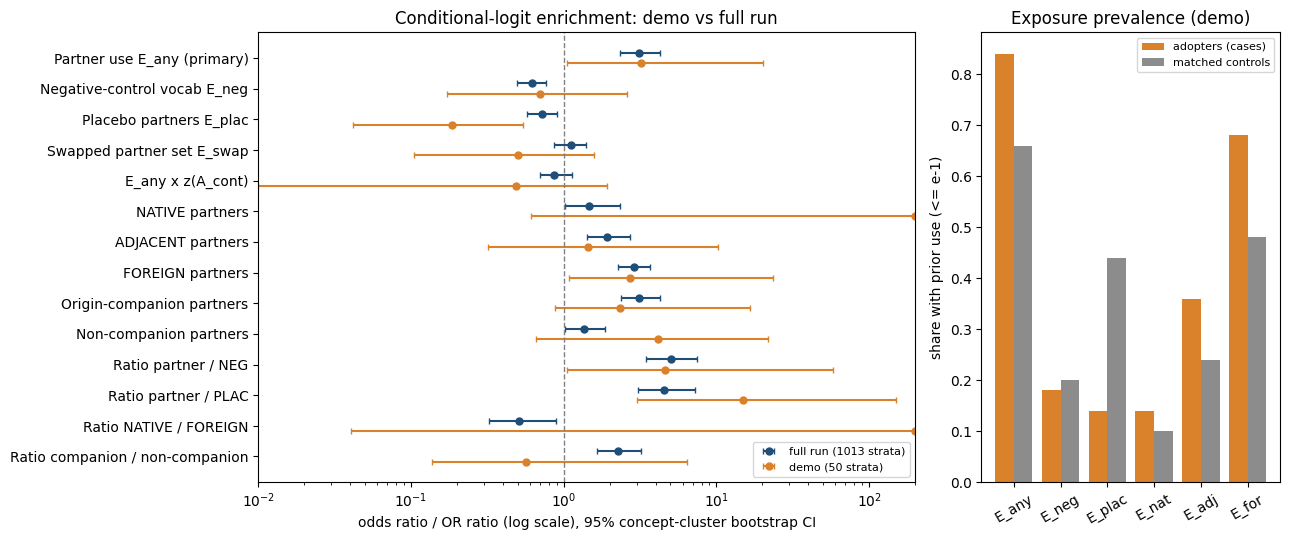

In [13]:
ref = data["full_run_reference"]
rows = []
show = [("m2", "E_any", "Partner use E_any (primary)"), ("m2", "E_neg", "Negative-control vocab E_neg"),
        ("m_plac", "E_plac", "Placebo partners E_plac"), ("m_swap", "E_swap", "Swapped partner set E_swap"),
        ("m_int", "E_any_x_zA", "E_any x z(A_cont)"), ("m_voc", "E_nat", "NATIVE partners"),
        ("m_voc", "E_adj", "ADJACENT partners"), ("m_voc", "E_for", "FOREIGN partners"),
        ("m_comp", "E_comp", "Origin-companion partners"), ("m_comp", "E_noncomp", "Non-companion partners")]
allfits = {**res["enrichment"], **res["interaction"], **res["vocab_class"]}
for m, term, lab in show:
    tt = (allfits[m].get("terms") or {}).get(term, {})
    ci = tt.get("OR_ci95_boot") or [np.nan, np.nan]
    r = ref["ORs"].get(f"{m}_{term}", {})
    rows.append({"term": lab, "demo_OR": tt.get("OR"), "demo_lo": ci[0], "demo_hi": ci[1],
                 "full_OR": r.get("OR"), "full_lo": r.get("ci", [None, None])[0], "full_hi": r.get("ci", [None, None])[1]})
for rk, lab in [("partner_over_neg", "Ratio partner / NEG"), ("partner_over_plac", "Ratio partner / PLAC"),
                ("native_vs_foreign", "Ratio NATIVE / FOREIGN"), ("companion_vs_noncompanion", "Ratio companion / non-companion")]:
    rr = res["ratios"].get(rk, {})
    ci = rr.get("ci95_boot") or [np.nan, np.nan]
    r = ref["ORs"].get(f"ratio_{rk}", {})
    rows.append({"term": lab, "demo_OR": rr.get("ratio"), "demo_lo": ci[0], "demo_hi": ci[1],
                 "full_OR": r.get("OR"), "full_lo": r["ci"][0], "full_hi": r["ci"][1]})
T = pd.DataFrame(rows).set_index("term").astype(float)
pd.set_option("display.width", 160)
print(f"Demo: {res['descriptives']['n_strata']} strata, B={B}   |   Full run: {ref['n_strata']} strata, B={ref['B']}")
print(T.to_string(float_format=lambda v: f"{v:.3g}" if abs(v) < 1e3 else f"{v:.1e}"))
print(f"\nPermutation null mean OR: demo {res['permutation']['mean_OR']:.2f} | full {ref['permutation_mean_OR']:.2f}")
print(f"Pre-declared verdict: demo = {res['reading']['verdict']}  |  full run = {ref['reading']['verdict']}")
print(f"Vocabulary reading (demo): {res['reading']['vocabulary']}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={"width_ratios": [2.2, 1]})
ax = axes[0]
y = np.arange(len(T))[::-1]
for off, pre_, col, lab in [(0.17, "full", "#1f4e79", f"full run ({ref['n_strata']} strata)"),
                            (-0.17, "demo", "#d9822b", f"demo ({res['descriptives']['n_strata']} strata)")]:
    o, lo, hi = (T[f"{pre_}_{c}"].clip(0.01, 200) for c in ("OR", "lo", "hi"))
    err = np.vstack([(o - lo).clip(lower=0).fillna(0), (hi - o).clip(lower=0).fillna(0)])
    ax.errorbar(o, y + off, xerr=err, fmt="o", color=col, ms=5, capsize=2, label=lab)
ax.axvline(1, color="grey", ls="--", lw=1)
ax.set_xscale("log")
ax.set_xlim(0.01, 200)   # display only: a separated point estimate in the 50-stratum demo is drawn at the edge
ax.set_yticks(y)
ax.set_yticklabels(T.index)
ax.set_xlabel("odds ratio / OR ratio (log scale), 95% concept-cluster bootstrap CI")
ax.set_title("Conditional-logit enrichment: demo vs full run")
ax.legend(loc="lower right", fontsize=8)
ax = axes[1]
ds = res["descriptives"]
cats = ["E_any", "E_neg", "E_plac", "E_nat", "E_adj", "E_for"]
xx = np.arange(len(cats))
ax.bar(xx - 0.2, [ds[f"prev_case_{c}"] for c in cats], 0.4, color="#d9822b", label="adopters (cases)")
ax.bar(xx + 0.2, [ds[f"prev_control_{c}"] for c in cats], 0.4, color="#8c8c8c", label="matched controls")
ax.set_xticks(xx)
ax.set_xticklabels(cats, rotation=30)
ax.set_ylabel("share with prior use (<= e-1)")
ax.set_title("Exposure prevalence (demo)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()